In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)

df = pd.read_csv('senate_campaign_data_by_zip.csv')
print('shape: ', df.shape)
df.head()

shape:  (304518, 18)


,YEAR,ZIP_CODE,STATE,CAND_OFFICE_ST,CAND_PTY_AFFILIATION,TRANSACTION_AMT,population,median_income,educ_attainment_pop_18plus,college_degree_or_higher_count_18plus,prop_college_degree_or_higher_18plus,high_school_or_higher_count_18plus,prop_high_school_or_higher_18plus,election_2020,election_2022,election_diff,lat,lon
0,2020,1001,MA,AZ,DEM,330,16984,75342,13438,4639,0.345215,12605,0.938012,1,0,-1,42.0702,-72.6227
1,2020,1001,MA,AZ,REP,290,16984,75342,13438,4639,0.345215,12605,0.938012,1,0,-1,42.0702,-72.6227
2,2020,1001,MA,CO,DEM,250,16984,75342,13438,4639,0.345215,12605,0.938012,1,0,-1,42.0702,-72.6227
3,2020,1001,MA,GA,DEM,260,16984,75342,13438,4639,0.345215,12605,0.938012,1,0,-1,42.0702,-72.6227
4,2020,1001,MA,IA,DEM,350,16984,75342,13438,4639,0.345215,12605,0.938012,1,0,-1,42.0702,-72.6227


# Minor Cleaning For Regression Model

In [2]:
# subset to only democrats or republicans
print('DROPPING THIRD PARTIES')
num = len(df)
df = df[df['CAND_PTY_AFFILIATION'].isin(['DEM', 'REP'])]
print('number datapoints before: ', num)
print('number datapoints after: ', len(df))

DROPPING THIRD PARTIES
number datapoints before:  304518
number datapoints after:  302273


In [3]:
print('DROPPING NEGATIVE DONATIONS')
num = len(df)
df = df[df['TRANSACTION_AMT'] > 1]
print('number datapoints before: ', num)
print('number datapoints after: ', len(df))

# log transform outcome
df['LOG_DONATIONS'] = np.log(df['TRANSACTION_AMT'])
df[['TRANSACTION_AMT', 'LOG_DONATIONS']]

DROPPING NEGATIVE DONATIONS
number datapoints before:  302273
number datapoints after:  301237


,TRANSACTION_AMT,LOG_DONATIONS
0,330,5.799093
1,290,5.669881
2,250,5.521461
3,260,5.560682
4,350,5.857933
...,...,...
304512,5604,8.631236
304513,5650,8.639411
304514,900,6.802395
304516,4454,8.401558


In [4]:
# standardize covariates (avoid massive scales)

for col in ["population", "median_income", "prop_college_degree_or_higher_18plus"]:
    df[col + "_z"] = (df[col] - df[col].mean()) / df[col].std()

# Baseline Model

Question: how much is a given zip code expected to donate to a given senate campaign (a state/party)?

Baseline model: donations = (candidate party) + (indicator for in-state) + (zip code population) + (zip code median income) + (zip code education, college)

In [5]:
# MODEL 1
import statsmodels.formula.api as smf

df['in_state'] = (df['STATE'] == df['CAND_OFFICE_ST']).astype(int)

formula = (
    'LOG_DONATIONS ~ '
    'C(CAND_PTY_AFFILIATION) + '
    'in_state + '
    'population_z + '
    'median_income_z + '
    'prop_college_degree_or_higher_18plus_z'
)

model_1 = smf.ols(formula, data=df).fit(cov_type='HC3')
print(model_1.summary())


                            OLS Regression Results                            
Dep. Variable:          LOG_DONATIONS   R-squared:                       0.200
Model:                            OLS   Adj. R-squared:                  0.200
Method:                 Least Squares   F-statistic:                 1.362e+04
Date:                Sat, 16 May 2026   Prob (F-statistic):               0.00
Time:                        11:52:11   Log-Likelihood:            -5.3957e+05
No. Observations:              301237   AIC:                         1.079e+06
Df Residuals:                  301231   BIC:                         1.079e+06
Df Model:                           5                                         
Covariance Type:                  HC3                                         
                                             coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------

In [6]:
# MODEL 2 - omit education (just keep income)
import statsmodels.formula.api as smf

df['in_state'] = (df['STATE'] == df['CAND_OFFICE_ST']).astype(int)

formula = (
    'LOG_DONATIONS ~ '
    'C(CAND_PTY_AFFILIATION) + '
    'in_state + '
    'population_z + '
    'median_income_z'
)

model_2 = smf.ols(formula, data=df).fit(cov_type='HC3')
print(model_2.summary())


                            OLS Regression Results                            
Dep. Variable:          LOG_DONATIONS   R-squared:                       0.117
Model:                            OLS   Adj. R-squared:                  0.117
Method:                 Least Squares   F-statistic:                     8926.
Date:                Sat, 16 May 2026   Prob (F-statistic):               0.00
Time:                        11:52:12   Log-Likelihood:            -5.5428e+05
No. Observations:              301237   AIC:                         1.109e+06
Df Residuals:                  301232   BIC:                         1.109e+06
Df Model:                           4                                         
Covariance Type:                  HC3                                         
                                     coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
Intercept   

I would like to ideally answer the question: "How do we model financial donation flows from a given zip code to a given campaign (in some state and affiliated with some party)? What are the determinants?" Thus aggregating at the zip code level would perhaps remove some of that info; perhaps subsetting (at least by party, or perhaps just to campaigns in competitive races) makes sense. 

Also considering running this on 2020 data and testing on 2022 data (perhaps with some big shift because it's not a presidential election year). Later.

# Gravity Model — Phase 0: Data Prep

Building a spatial gravity model of donation flows. Unit of analysis: (origin ZIP × destination state-party) dyad. Before feature engineering, verify data integrity and flag assumptions.

In [7]:
import time

# --- Verify pre-aggregation ---
group_sizes = df.groupby(['ZIP_CODE', 'CAND_OFFICE_ST', 'CAND_PTY_AFFILIATION', 'YEAR']).size()
assert group_sizes.max() == 1, f"Data not pre-aggregated! Max group size: {group_sizes.max()}"
print("✓ Pre-aggregated: all (ZIP × dest × party × year) groups have size 1")

# --- Verify election columns key to origin state, not destination ---
elec_varies_in_dest = (df.groupby('CAND_OFFICE_ST')['election_2020'].nunique() > 1).any()
elec_varies_in_origin = (df.groupby('STATE')['election_2020'].nunique() > 1).any()
if elec_varies_in_dest and not elec_varies_in_origin:
    print("⚠ election_2020/2022 key to origin STATE, not destination CAND_OFFICE_ST.")
    print("  Subsetting will use YEAR directly; all CAND_OFFICE_ST values in a given")
    print("  year are the destination states with races that year.")
elif not elec_varies_in_dest:
    print("✓ election_2020/2022 key to destination CAND_OFFICE_ST (constant within dest state)")

# --- Inspect election_diff ---
print(f"\nelection_diff value counts:\n{df['election_diff'].value_counts().to_dict()}")
print("Interpretation: keys to origin STATE — 1=had 2020 race only, -1=had 2022 race only, 0=both or neither")

# --- ZIP zero-padding ---
df['ZIP_CODE'] = df['ZIP_CODE'].astype(str).str.zfill(5)
print(f"\n✓ ZIP codes zero-padded. Sample: {df['ZIP_CODE'].head(3).tolist()}")

✓ Pre-aggregated: all (ZIP × dest × party × year) groups have size 1
⚠ election_2020/2022 key to origin STATE, not destination CAND_OFFICE_ST.
  Subsetting will use YEAR directly; all CAND_OFFICE_ST values in a given
  year are the destination states with races that year.

election_diff value counts:
{1: 138663, -1: 84509, 0: 78065}
Interpretation: keys to origin STATE — 1=had 2020 race only, -1=had 2022 race only, 0=both or neither

✓ ZIP codes zero-padded. Sample: ['01001', '01001', '01001']


In [8]:
from pyproj import Transformer

t0 = time.time()

# Population-weighted state centroids (from ZIP data, no external shapefile)
# Use all unique ZIPs to represent each state's geography
zip_level = df.drop_duplicates('ZIP_CODE')[['ZIP_CODE', 'STATE', 'lat', 'lon', 'population']].copy()

state_centroids = (
    zip_level.groupby('STATE')
    .apply(lambda g: pd.Series({
        'centroid_lat': np.average(g['lat'], weights=g['population']),
        'centroid_lon': np.average(g['lon'], weights=g['population']),
    }))
    .reset_index()
)

# Project to EPSG:5070 (Albers Equal Area, meters) for accurate distance
transformer = Transformer.from_crs("EPSG:4326", "EPSG:5070", always_xy=True)

cx, cy = transformer.transform(state_centroids['centroid_lon'].values,
                               state_centroids['centroid_lat'].values)
state_centroids['cx_5070'] = cx
state_centroids['cy_5070'] = cy
# Rename for merge on destination state
state_centroids_dest = state_centroids.rename(columns={'STATE': 'CAND_OFFICE_ST',
                                                        'cx_5070': 'dest_cx',
                                                        'cy_5070': 'dest_cy'})

# Project origin ZIP centroids
ox, oy = transformer.transform(zip_level['lon'].values, zip_level['lat'].values)
zip_level = zip_level.copy()
zip_level['ox_5070'] = ox
zip_level['oy_5070'] = oy

# Merge projected origin and destination coordinates into df
df = df.merge(zip_level[['ZIP_CODE', 'ox_5070', 'oy_5070']], on='ZIP_CODE', how='left')
df = df.merge(state_centroids_dest[['CAND_OFFICE_ST', 'dest_cx', 'dest_cy']],
              on='CAND_OFFICE_ST', how='left')

# Haversine-free Euclidean distance in projected CRS (meters → km)
df['distance_km'] = np.sqrt((df['ox_5070'] - df['dest_cx'])**2 +
                            (df['oy_5070'] - df['dest_cy'])**2) / 1000.0
df['log_dist'] = np.log1p(df['distance_km'])

print(f"Distance computed in {time.time()-t0:.1f}s")
print(f"distance_km: min={df['distance_km'].min():.0f}  median={df['distance_km'].median():.0f}  max={df['distance_km'].max():.0f}")
print(f"In-state rows (distance_km < 200): {(df['distance_km'] < 200).mean():.1%}")

Distance computed in 0.1s
distance_km: min=0  median=1351  max=4430
In-state rows (distance_km < 200): 7.4%


In [9]:
# Standardize all continuous predictors (z-score across full dataset before splitting by year)
# population_z, median_income_z, prop_college_degree_or_higher_18plus_z already exist from above

for col, zname in [
    ('prop_high_school_or_higher_18plus', 'hs_z'),
    ('log_dist', 'log_dist_z'),
]:
    df[zname] = (df[col] - df[col].mean()) / df[col].std()

print("Standardized predictors:", ['population_z', 'median_income_z',
      'prop_college_degree_or_higher_18plus_z', 'hs_z', 'log_dist_z'])

# Subset by year (election_2020/2022 keys to origin, so use YEAR directly)
df_2020 = df[df['YEAR'] == 2020].copy()
df_2022 = df[df['YEAR'] == 2022].copy()

print(f"\n2020 subset: {len(df_2020):,} rows | {df_2020['ZIP_CODE'].nunique():,} origin ZIPs | "
      f"{df_2020['CAND_OFFICE_ST'].nunique()} destination states")
print(f"2022 subset: {len(df_2022):,} rows | {df_2022['ZIP_CODE'].nunique():,} origin ZIPs | "
      f"{df_2022['CAND_OFFICE_ST'].nunique()} destination states")

# Cache to CSV (used by R script below)
df_2020.to_csv('model_data_2020.csv', index=False)
df_2022.to_csv('model_data_2022.csv', index=False)
print("\nWrote model_data_2020.csv and model_data_2022.csv")

Standardized predictors: ['population_z', 'median_income_z', 'prop_college_degree_or_higher_18plus_z', 'hs_z', 'log_dist_z']

2020 subset: 157,757 rows | 17,473 origin ZIPs | 34 destination states
2022 subset: 143,480 rows | 16,117 origin ZIPs | 34 destination states

Wrote model_data_2020.csv and model_data_2022.csv


# Gravity Model — Phase 1: Spatial Model (R `mgcv`)

Fitting three models on 2020 positive flows:
- **Model A** — OLS with distance added (no spatial, for comparison)
- **Model B** — `bam()` with `s(lon, lat, bs="gp", k=200)` Gaussian-process spatial field (headline)
- **Model C** — Model B + `CAND_OFFICE_ST` destination fixed effects

The R script is written and executed in the cell below. Note: standard errors are from mgcv's Bayesian posterior (not cluster-robust); with N≈150k rows near-everything is "significant" so we focus on effect sizes (`exp(b)−1` per SD).

In [10]:
import subprocess, os, textwrap

R_SCRIPT = textwrap.dedent("""\
library(mgcv)
library(data.table)

cat("Reading model_data_2020.csv...\\n")
df <- fread("model_data_2020.csv")
df$CAND_PTY_AFFILIATION <- factor(df$CAND_PTY_AFFILIATION)
df$CAND_OFFICE_ST       <- factor(df$CAND_OFFICE_ST)

structural_terms <- c(
  "(Intercept)", "population_z", "median_income_z",
  "prop_college_degree_or_higher_18plus_z", "hs_z",
  "CAND_PTY_AFFILIATIONREP", "in_state", "log_dist_z"
)

extract_coefs <- function(model, model_name) {
  if (inherits(model, "gam")) {
    ct <- as.data.frame(summary(model)$p.table)
  } else {
    ct <- as.data.frame(summary(model)$coefficients)
  }
  names(ct) <- c("estimate","std_error","t_value","p_value")
  ct$term  <- rownames(ct)
  ct$model <- model_name
  ct$exp_b_minus_1 <- exp(ct$estimate) - 1
  ct[ct$term %in% structural_terms,
     c("model","term","estimate","std_error","t_value","p_value","exp_b_minus_1")]
}

# --- Model A: OLS with distance (no spatial) ---
cat("Fitting OLS baseline...\\n"); t0 <- proc.time()
m_ols <- lm(
  LOG_DONATIONS ~ population_z + median_income_z +
    prop_college_degree_or_higher_18plus_z + hs_z +
    CAND_PTY_AFFILIATION + in_state + log_dist_z,
  data = df
)
cat("  done in", round((proc.time()-t0)["elapsed"],1), "sec\\n")

# --- Model B: GP spatial (headline) ---
cat("Fitting GP spatial model (k=200)...\\n"); t0 <- proc.time()
m_gp <- bam(
  LOG_DONATIONS ~ population_z + median_income_z +
    prop_college_degree_or_higher_18plus_z + hs_z +
    CAND_PTY_AFFILIATION + in_state + log_dist_z +
    s(lon, lat, bs = "gp", k = 200),
  data = df, discrete = TRUE, nthreads = 4
)
cat("  done in", round((proc.time()-t0)["elapsed"],1), "sec\\n")

# --- Model C: GP spatial + destination FE ---
cat("Fitting GP spatial + destination FE...\\n"); t0 <- proc.time()
m_gp_fe <- bam(
  LOG_DONATIONS ~ population_z + median_income_z +
    prop_college_degree_or_higher_18plus_z + hs_z +
    CAND_PTY_AFFILIATION + in_state + log_dist_z +
    CAND_OFFICE_ST +
    s(lon, lat, bs = "gp", k = 200),
  data = df, discrete = TRUE, nthreads = 4
)
cat("  done in", round((proc.time()-t0)["elapsed"],1), "sec\\n")

# --- Coefficient comparison ---
coef_all <- rbind(
  extract_coefs(m_ols,    "A_OLS_dist"),
  extract_coefs(m_gp,     "B_GP_spatial"),
  extract_coefs(m_gp_fe,  "C_GP_spatial_destFE")
)
write.csv(coef_all, "coef_comparison.csv", row.names = FALSE)

# --- Smooth term table ---
sm_tab <- as.data.frame(summary(m_gp)$s.table)
sm_tab$term <- rownames(sm_tab)
write.csv(sm_tab, "smooth_summary.csv", row.names = FALSE)

# --- Fit statistics ---
fit_stats <- data.frame(
  model        = c("A_OLS_dist", "B_GP_spatial", "C_GP_spatial_destFE"),
  r_squared    = c(summary(m_ols)$r.squared, summary(m_gp)$r.sq,  summary(m_gp_fe)$r.sq),
  dev_explained= c(NA, summary(m_gp)$dev.expl, summary(m_gp_fe)$dev.expl),
  AIC          = c(AIC(m_ols), AIC(m_gp), AIC(m_gp_fe))
)
write.csv(fit_stats, "model_fit_stats.csv", row.names = FALSE)

# --- Spatial field: prediction grid (lon/lat over continental US) ---
grid <- expand.grid(
  lon = seq(-125, -66, length.out = 120),
  lat = seq(  25,  50, length.out = 80)
)
grid$population_z <- 0; grid$median_income_z <- 0
grid$prop_college_degree_or_higher_18plus_z <- 0; grid$hs_z <- 0
grid$CAND_PTY_AFFILIATION <- factor("DEM", levels = levels(df$CAND_PTY_AFFILIATION))
grid$in_state <- 0; grid$log_dist_z <- 0

pred_terms   <- predict(m_gp, newdata = grid, type = "terms")
sp_col       <- grep("s\\\\(lon", colnames(pred_terms), value = TRUE)[1]
grid$spatial_effect <- pred_terms[, sp_col]
write.csv(grid[, c("lon","lat","spatial_effect")], "spatial_field_grid.csv", row.names = FALSE)

# --- Fitted values for diagnostics ---
# Use predict(newdata=df) instead of fitted() to get full-length output
# (bam with discrete=TRUE drops incomplete cases, so fitted() may be shorter than nrow(df))
df_base <- as.data.frame(df)
df_base$fitted_gp  <- predict(m_gp,  newdata = df_base, type = "response")
df_base$fitted_ols <- predict(m_ols, newdata = df_base)
df_base$resid_gp   <- df_base$LOG_DONATIONS - df_base$fitted_gp
write.csv(df_base[, c("LOG_DONATIONS","fitted_gp","fitted_ols","resid_gp",
                      "ZIP_CODE","CAND_OFFICE_ST","CAND_PTY_AFFILIATION","in_state")],
          "fitted_values_2020.csv", row.names = FALSE)
cat("Wrote fitted_values_2020.csv\\n")

# --- 2022 predictions for train/test ---
df22 <- as.data.frame(fread("model_data_2022.csv"))
df22$CAND_PTY_AFFILIATION <- factor(df22$CAND_PTY_AFFILIATION,
                                    levels = levels(df$CAND_PTY_AFFILIATION))
df22$pred_gp  <- predict(m_gp,  newdata = df22, type = "response")
df22$pred_ols <- predict(m_ols, newdata = df22)
write.csv(df22[, c("LOG_DONATIONS","pred_gp","pred_ols",
                   "ZIP_CODE","CAND_OFFICE_ST","CAND_PTY_AFFILIATION","in_state")],
          "preds_2022.csv", row.names = FALSE)
cat("Wrote preds_2022.csv\\n")

cat("All outputs written.\\n")
""")

script_path = os.path.join(os.getcwd(), '02_fit.R')
with open(script_path, 'w') as f:
    f.write(R_SCRIPT)

print("Running R spatial model — this may take 1–5 minutes...")
t0 = time.time()
result = subprocess.run(
    ['Rscript', script_path],
    capture_output=True, text=True,
    cwd=os.getcwd()
)
elapsed = time.time() - t0
print(result.stdout)
if result.stderr:
    print("STDERR:", result.stderr[-3000:])
print(f"Total wall time: {elapsed:.1f}s")

Running R spatial model — this may take 1–5 minutes...
Reading model_data_2020.csv...
Fitting OLS baseline...
  done in 0.1 sec
Fitting GP spatial model (k=200)...
  done in 1 sec
Fitting GP spatial + destination FE...
  done in 0.9 sec
Wrote fitted_values_2020.csv
Wrote preds_2022.csv
All outputs written.

STDERR: Loading required package: nlme
This is mgcv 1.9-3. For overview type 'help("mgcv-package")'.
Warning message:
In bam(LOG_DONATIONS ~ population_z + median_income_z + prop_college_degree_or_higher_18plus_z +  :
  openMP not available: single threaded computation only
Warning message:
In bam(LOG_DONATIONS ~ population_z + median_income_z + prop_college_degree_or_higher_18plus_z +  :
  openMP not available: single threaded computation only

Total wall time: 4.8s


In [11]:
coef_df = pd.read_csv('coef_comparison.csv')
fit_df  = pd.read_csv('model_fit_stats.csv')
smooth_df = pd.read_csv('smooth_summary.csv')

print("=== Model fit statistics ===")
print(fit_df.to_string(index=False))

print("\n=== Smooth term (GP spatial field) ===")
print(smooth_df.to_string(index=False))

# Pivot for side-by-side coefficient comparison
term_order = ["(Intercept)", "population_z", "median_income_z",
              "prop_college_degree_or_higher_18plus_z", "hs_z",
              "CAND_PTY_AFFILIATIONREP", "in_state", "log_dist_z"]

label_map = {
    "(Intercept)": "Intercept",
    "population_z": "log(population) [per SD]",
    "median_income_z": "log(median income) [per SD]",
    "prop_college_degree_or_higher_18plus_z": "College% [per SD]",
    "hs_z": "HS% [per SD]",
    "CAND_PTY_AFFILIATIONREP": "Party: REP vs DEM",
    "in_state": "In-state indicator",
    "log_dist_z": "log(distance km) [per SD]",
}

pivot = (
    coef_df[coef_df['term'].isin(term_order)]
    .pivot(index='term', columns='model', values=['estimate', 'exp_b_minus_1'])
    .reindex(term_order)
)
pivot.index = [label_map.get(t, t) for t in pivot.index]
pivot.columns = [f"{c[1]}\n{c[0]}" for c in pivot.columns]

print("\n=== Coefficient comparison: estimate (and exp(b)−1 per SD) ===")
print(pivot.round(4).to_string())

=== Model fit statistics ===
              model  r_squared  dev_explained           AIC
         A_OLS_dist   0.205373            NaN 561631.147729
       B_GP_spatial   0.222988       0.223746 558241.870392
C_GP_spatial_destFE   0.304723       0.305600 540784.342815

=== Smooth term (GP spatial field) ===
       edf  Ref.df         F  p-value       term
146.617986      87 35.955281        0 s(lon,lat)

=== Coefficient comparison: estimate (and exp(b)−1 per SD) ===
                             A_OLS_dist\nestimate  B_GP_spatial\nestimate  C_GP_spatial_destFE\nestimate  A_OLS_dist\nexp_b_minus_1  B_GP_spatial\nexp_b_minus_1  C_GP_spatial_destFE\nexp_b_minus_1
Intercept                                  6.1194                  6.1056                         5.6158                   453.5921                     447.3398                            273.7375
log(population) [per SD]                   0.2203                  0.2044                         0.2480                     0.2465    

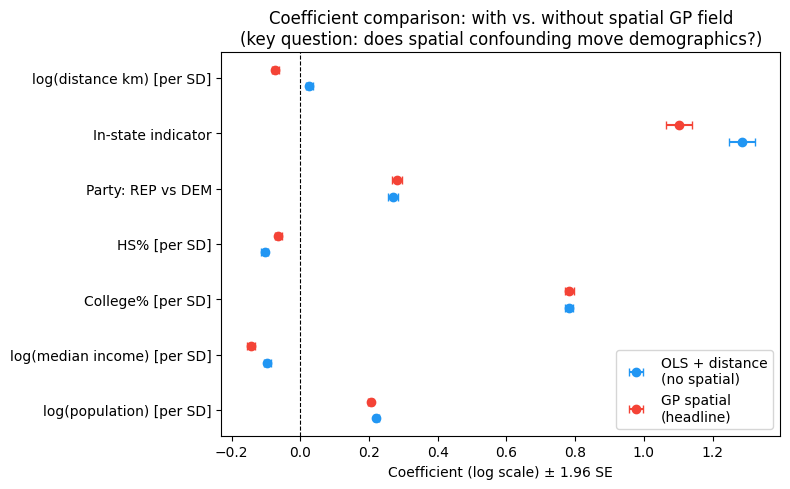

In [12]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.colors import TwoSlopeNorm

# Forest-plot style: coefficients for Models A and B (with/without spatial)
models_to_plot = ['A_OLS_dist', 'B_GP_spatial']
model_labels   = {'A_OLS_dist': 'OLS + distance\n(no spatial)', 'B_GP_spatial': 'GP spatial\n(headline)'}
colors = {'A_OLS_dist': '#2196F3', 'B_GP_spatial': '#F44336'}

terms_plot = ["population_z", "median_income_z",
              "prop_college_degree_or_higher_18plus_z", "hs_z",
              "CAND_PTY_AFFILIATIONREP", "in_state", "log_dist_z"]
y_labels = [label_map[t] for t in terms_plot]

fig, ax = plt.subplots(figsize=(8, 5))
offsets = {'A_OLS_dist': -0.15, 'B_GP_spatial': 0.15}

for mod in models_to_plot:
    sub = coef_df[coef_df['model'] == mod].set_index('term')
    ests   = [sub.loc[t, 'estimate']   if t in sub.index else np.nan for t in terms_plot]
    ses    = [sub.loc[t, 'std_error']  if t in sub.index else np.nan for t in terms_plot]
    ys     = [i + offsets[mod] for i in range(len(terms_plot))]
    ax.errorbar(ests, ys, xerr=[1.96*s for s in ses],
                fmt='o', color=colors[mod], label=model_labels[mod],
                capsize=3, linewidth=1.5, markersize=6)

ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_yticks(range(len(terms_plot)))
ax.set_yticklabels(y_labels)
ax.set_xlabel("Coefficient (log scale) ± 1.96 SE")
ax.set_title("Coefficient comparison: with vs. without spatial GP field\n(key question: does spatial confounding move demographics?)")
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('coef_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

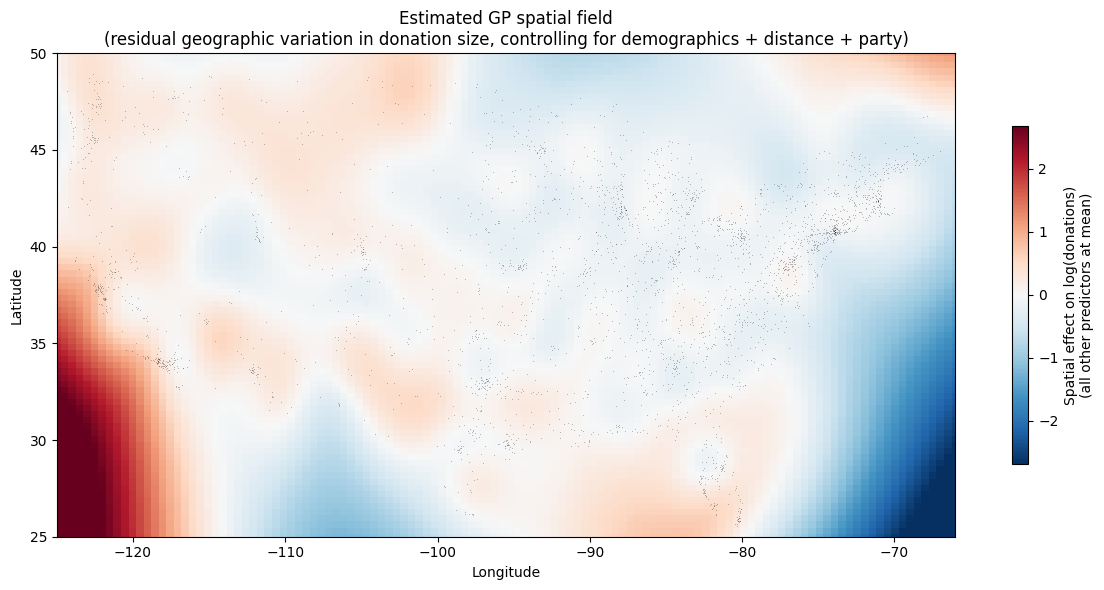

In [13]:
# Spatial field map over continental US
grid_df = pd.read_csv('spatial_field_grid.csv')

fig, ax = plt.subplots(figsize=(12, 6))
grid_pivot = grid_df.pivot(index='lat', columns='lon', values='spatial_effect')

vmax = grid_df['spatial_effect'].abs().quantile(0.98)
norm = TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)

im = ax.pcolormesh(
    grid_pivot.columns, grid_pivot.index, grid_pivot.values,
    cmap='RdBu_r', norm=norm, shading='auto'
)
cbar = plt.colorbar(im, ax=ax, shrink=0.7)
cbar.set_label('Spatial effect on log(donations)\n(all other predictors at mean)')

# Overlay actual ZIP locations (sample to avoid overplotting)
sample_zips = df_2020.drop_duplicates('ZIP_CODE').sample(min(3000, df_2020['ZIP_CODE'].nunique()), random_state=1)
ax.scatter(sample_zips['lon'], sample_zips['lat'], s=0.3, c='k', alpha=0.3, linewidths=0)

ax.set_xlim(-125, -66)
ax.set_ylim(25, 50)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Estimated GP spatial field\n(residual geographic variation in donation size, controlling for demographics + distance + party)')
plt.tight_layout()
plt.savefig('spatial_field_map.png', dpi=150, bbox_inches='tight')
plt.show()

# Gravity Model — Phase 7: Train 2020 → Test 2022

The GP model is fit on 2020 data; predictions on 2022 test the transferability of the estimated spatial field and coefficients across a presidential→midterm shift. Expect a **level shift** (lower total donations in midterms), so we care about pattern transfer (R², correlation) as well as raw RMSE.

Also: refit the same GP spec on 2022 alone and compare coefficient vectors — tests stability of determinants across election cycles.

In [14]:
preds22_raw = pd.read_csv('preds_2022.csv')
preds22 = preds22_raw.dropna(subset=['pred_gp', 'pred_ols'])

n_dropped = len(preds22_raw) - len(preds22)
if n_dropped:
    print(f"Note: dropped {n_dropped} rows with NA predictions (dest states outside GP training support)\n")

y_true = preds22['LOG_DONATIONS']
y_gp   = preds22['pred_gp']
y_ols  = preds22['pred_ols']

def metrics(y_true, y_pred, label):
    residuals = y_true - y_pred
    rmse = np.sqrt((residuals**2).mean())
    ss_res = (residuals**2).sum()
    ss_tot = ((y_true - y_true.mean())**2).sum()
    r2 = 1 - ss_res / ss_tot
    corr = np.corrcoef(y_true, y_pred)[0, 1]
    print(f"{label:30s}  RMSE={rmse:.4f}  R²={r2:.4f}  corr={corr:.4f}  mean_bias={residuals.mean():.4f}")

print("Out-of-year (2020→2022) predictive performance:")
metrics(y_true, y_gp,  "GP spatial (trained 2020)")
metrics(y_true, y_ols, "OLS + dist  (trained 2020)")
print()

fit20_mean = pd.read_csv('fitted_values_2020.csv')['LOG_DONATIONS'].mean()
print(f"Mean log-donation: 2020={fit20_mean:.3f}  2022={y_true.mean():.3f}  "
      f"shift={y_true.mean()-fit20_mean:.3f}  (expect uniform bias ≈ this)")

Note: dropped 786 rows with NA predictions (dest states outside GP training support)

Out-of-year (2020→2022) predictive performance:
GP spatial (trained 2020)       RMSE=1.4765  R²=0.1618  corr=0.4525  mean_bias=-0.3311
OLS + dist  (trained 2020)      RMSE=1.4868  R²=0.1501  corr=0.4379  mean_bias=-0.3274

Mean log-donation: 2020=6.349  2022=6.025  shift=-0.324  (expect uniform bias ≈ this)


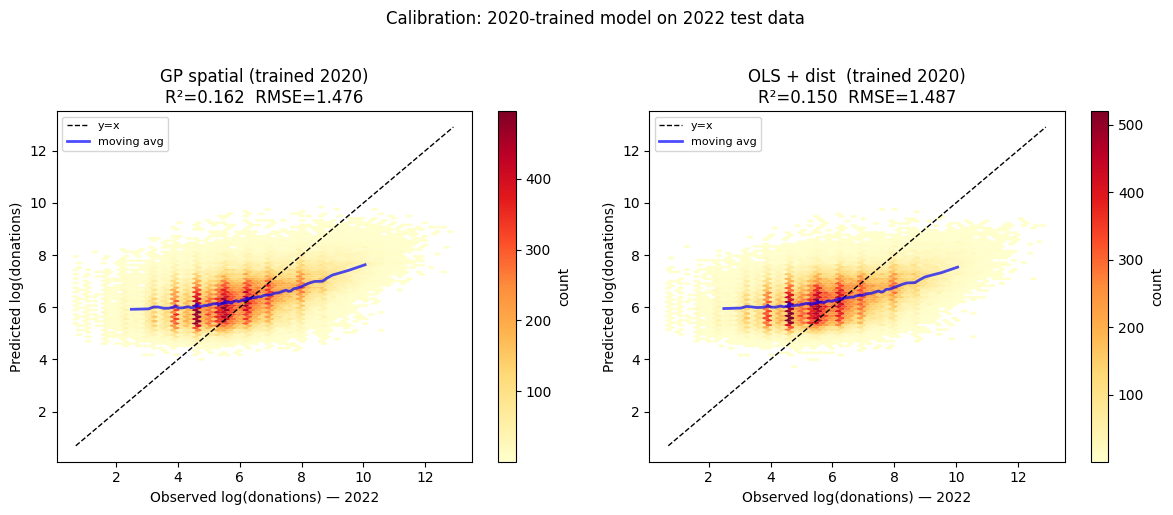

In [15]:
# Calibration plot: observed vs predicted log-donations (2022 test set)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (y_pred, label, color) in zip(axes, [
    (y_gp,  'GP spatial (trained 2020)', '#F44336'),
    (y_ols, 'OLS + dist  (trained 2020)', '#2196F3'),
]):
    # Hexbin for density
    hb = ax.hexbin(y_true, y_pred, gridsize=60, cmap='YlOrRd', mincnt=1, linewidths=0.1)
    plt.colorbar(hb, ax=ax, label='count')
    lo, hi = min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())
    ax.plot([lo, hi], [lo, hi], 'k--', linewidth=1, label='y=x')
    
    # Loess-style moving-window trend line
    sorted_idx = np.argsort(y_true.values)
    x_s = y_true.values[sorted_idx]
    y_s = y_pred.values[sorted_idx]
    window = max(1, len(x_s) // 50)
    trend_x = [x_s[i:i+window].mean() for i in range(0, len(x_s)-window, window//2)]
    trend_y = [y_s[i:i+window].mean() for i in range(0, len(x_s)-window, window//2)]
    ax.plot(trend_x, trend_y, 'b-', linewidth=2, alpha=0.7, label='moving avg')
    
    resid = y_true - y_pred
    r2 = 1 - (resid**2).sum() / ((y_true - y_true.mean())**2).sum()
    ax.set_title(f'{label}\nR²={r2:.3f}  RMSE={np.sqrt((resid**2).mean()):.3f}')
    ax.set_xlabel('Observed log(donations) — 2022')
    ax.set_ylabel('Predicted log(donations)')
    ax.legend(fontsize=8)

plt.suptitle('Calibration: 2020-trained model on 2022 test data', y=1.02)
plt.tight_layout()
plt.savefig('calibration_2022.png', dpi=150, bbox_inches='tight')
plt.show()

In [16]:
# Refit GP model on 2022 data to test coefficient stability
R_STABILITY = textwrap.dedent("""\
library(mgcv); library(data.table)

df22 <- fread("model_data_2022.csv")
df22$CAND_PTY_AFFILIATION <- factor(df22$CAND_PTY_AFFILIATION)
df22$CAND_OFFICE_ST       <- factor(df22$CAND_OFFICE_ST)

cat("Fitting GP spatial model on 2022 data...\\n"); t0 <- proc.time()
m_gp22 <- bam(
  LOG_DONATIONS ~ population_z + median_income_z +
    prop_college_degree_or_higher_18plus_z + hs_z +
    CAND_PTY_AFFILIATION + in_state + log_dist_z +
    s(lon, lat, bs = "gp", k = 200),
  data = df22, discrete = TRUE, nthreads = 4
)
cat("  done in", round((proc.time()-t0)["elapsed"],1), "sec\\n")

structural_terms <- c(
  "(Intercept)", "population_z", "median_income_z",
  "prop_college_degree_or_higher_18plus_z", "hs_z",
  "CAND_PTY_AFFILIATIONREP", "in_state", "log_dist_z"
)
ct22 <- as.data.frame(summary(m_gp22)$p.table)
names(ct22) <- c("estimate","std_error","t_value","p_value")
ct22$term  <- rownames(ct22)
ct22$model <- "B_GP_spatial_2022"
ct22$exp_b_minus_1 <- exp(ct22$estimate) - 1
ct22 <- ct22[ct22$term %in% structural_terms,
             c("model","term","estimate","std_error","t_value","p_value","exp_b_minus_1")]
write.csv(ct22, "coef_2022.csv", row.names=FALSE)
cat("Wrote coef_2022.csv\\n")
""")

script_path_22 = os.path.join(os.getcwd(), '03_stability.R')
with open(script_path_22, 'w') as f:
    f.write(R_STABILITY)

print("Refitting GP on 2022 data for coefficient stability check...")
t0 = time.time()
result22 = subprocess.run(['Rscript', script_path_22], capture_output=True, text=True, cwd=os.getcwd())
print(result22.stdout)
if result22.stderr:
    print("STDERR:", result22.stderr[-2000:])
print(f"Wall time: {time.time()-t0:.1f}s")

Refitting GP on 2022 data for coefficient stability check...
Fitting GP spatial model on 2022 data...
  done in 0.9 sec
Wrote coef_2022.csv

STDERR: Loading required package: nlme
This is mgcv 1.9-3. For overview type 'help("mgcv-package")'.
Warning message:
In bam(LOG_DONATIONS ~ population_z + median_income_z + prop_college_degree_or_higher_18plus_z +  :
  openMP not available: single threaded computation only

Wall time: 1.4s


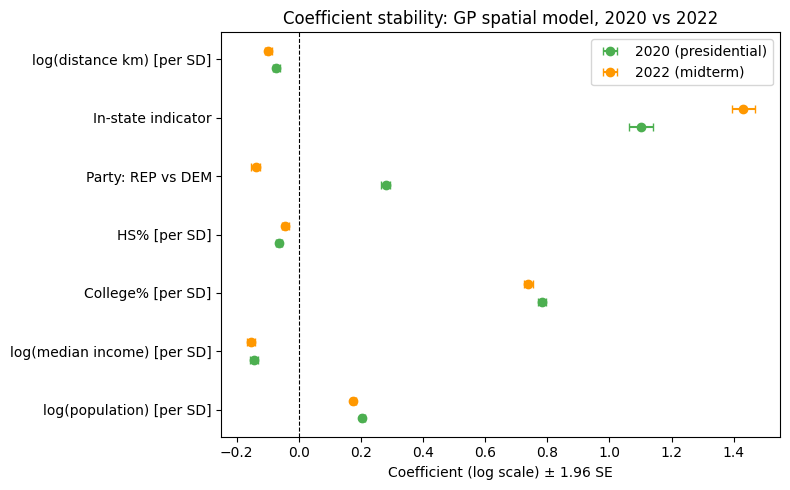

                             est_2020  est_2022   delta  pct_2020  pct_2022
Intercept                      6.1056    5.9586 -0.1470  447.3398  386.0553
log(population) [per SD]       0.2044    0.1753 -0.0291    0.2268    0.1916
log(median income) [per SD]   -0.1440   -0.1548 -0.0108   -0.1341   -0.1434
College% [per SD]              0.7832    0.7385 -0.0447    1.1885    1.0929
HS% [per SD]                  -0.0646   -0.0439  0.0207   -0.0626   -0.0430
Party: REP vs DEM              0.2802   -0.1394 -0.4196    0.3234   -0.1301
In-state indicator             1.1016    1.4303  0.3287    2.0089    3.1799
log(distance km) [per SD]     -0.0729   -0.0981 -0.0253   -0.0703   -0.0935


In [17]:
# Coefficient stability: GP model fit on 2020 vs 2022
coef22 = pd.read_csv('coef_2022.csv')
coef20 = coef_df[coef_df['model'] == 'B_GP_spatial'].copy()
coef20['model'] = 'B_GP_spatial_2020'

stability = pd.concat([coef20, coef22], ignore_index=True)

fig, ax = plt.subplots(figsize=(8, 5))
offsets_yr = {'B_GP_spatial_2020': -0.15, 'B_GP_spatial_2022': 0.15}
colors_yr  = {'B_GP_spatial_2020': '#4CAF50', 'B_GP_spatial_2022': '#FF9800'}
labels_yr  = {'B_GP_spatial_2020': '2020 (presidential)', 'B_GP_spatial_2022': '2022 (midterm)'}

for mod in ['B_GP_spatial_2020', 'B_GP_spatial_2022']:
    sub = stability[stability['model'] == mod].set_index('term')
    ests = [sub.loc[t, 'estimate']  if t in sub.index else np.nan for t in terms_plot]
    ses  = [sub.loc[t, 'std_error'] if t in sub.index else np.nan for t in terms_plot]
    ys   = [i + offsets_yr[mod] for i in range(len(terms_plot))]
    ax.errorbar(ests, ys, xerr=[1.96*s for s in ses],
                fmt='o', color=colors_yr[mod], label=labels_yr[mod],
                capsize=3, linewidth=1.5, markersize=6)

ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_yticks(range(len(terms_plot)))
ax.set_yticklabels(y_labels)
ax.set_xlabel("Coefficient (log scale) ± 1.96 SE")
ax.set_title("Coefficient stability: GP spatial model, 2020 vs 2022")
ax.legend()
plt.tight_layout()
plt.savefig('coef_stability_2020_2022.png', dpi=150, bbox_inches='tight')
plt.show()

# Print numeric comparison
comp = pd.merge(
    coef20[['term','estimate','exp_b_minus_1']].rename(columns={'estimate':'est_2020','exp_b_minus_1':'pct_2020'}),
    coef22[['term','estimate','exp_b_minus_1']].rename(columns={'estimate':'est_2022','exp_b_minus_1':'pct_2022'}),
    on='term'
)
comp['delta'] = comp['est_2022'] - comp['est_2020']
comp.index = [label_map.get(t,t) for t in comp['term']]
print(comp[['est_2020','est_2022','delta','pct_2020','pct_2022']].round(4).to_string())